In [1]:
# CMSC320 FINAL PROJECT: CHECKPOINT 2
# Arvind Kakanavaram, Yudiishbala Senthilkumar, Ethan Zhen

import pandas as pd
import requests
import json

# NYC Open Data API endpoint for Motor Vehicle Collisions
url = "https://data.cityofnewyork.us/api/views/h9gi-nx95/rows.json?accessType=DOWNLOAD"

# Download dataset
print("Downloading NYC Motor Vehicle Collisions dataset")
response = requests.get(url)
data = response.json()

# Extract data and metadata
columns = [col['name'] for col in data['meta']['view']['columns']]
rows = data['data']

# Create dataframe
crashes_df = pd.DataFrame(rows, columns=columns)

print(f"Dataset has been downloaded.")
print(f"Shape: {crashes_df.shape}")
print(f"\nColumns: {crashes_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(crashes_df.head())

Dataset has been downloaded.
Shape: (2269187, 37)

Columns: ['sid', 'id', 'position', 'created_at', 'created_meta', 'updated_at', 'updated_meta', 'meta', 'CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME', 'OFF STREET NAME', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5', 'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5']

First few rows:
                  sid                                    id  position  \
0  row-rsc3.wgwr-zpi9  00000000-0000-0000-2EDA-D04CF4F72CCD         0   
1  

In [2]:
# DATAPREPROCESSING

# Parse and convert data types
import numpy as np
from datetime import datetime

# Convert CRASH DATE and CRASH TIME to datetime
crashes_df['CRASH DATE'] = pd.to_datetime(crashes_df['CRASH DATE'], errors='coerce')
crashes_df['CRASH TIME'] = pd.to_datetime(crashes_df['CRASH TIME'], format='%H:%M', errors='coerce')

# Convert numeric columns to int
numeric_cols = ['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED', 
                 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
                 'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
                 'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
                 'LATITUDE', 'LONGITUDE']
for col in numeric_cols:
    crashes_df[col] = pd.to_numeric(crashes_df[col], errors='coerce')

# Target variable: whether or not injury occured
crashes_df['HAS_INJURY'] = (crashes_df['NUMBER OF PERSONS INJURED'] > 0).astype(int)

print("Data types after parsing:")
print(crashes_df.dtypes)
print(f"\nDataset shape: {crashes_df.shape}")
print(f"\nMissing values per column:")
print(crashes_df.isnull().sum())

Data types after parsing:
sid                                      object
id                                       object
position                                  int64
created_at                                int64
created_meta                             object
updated_at                                int64
updated_meta                             object
meta                                     object
CRASH DATE                       datetime64[ns]
CRASH TIME                       datetime64[ns]
BOROUGH                                  object
ZIP CODE                                 object
LATITUDE                                float64
LONGITUDE                               float64
LOCATION                                 object
ON STREET NAME                           object
CROSS STREET NAME                        object
OFF STREET NAME                          object
NUMBER OF PERSONS INJURED               float64
NUMBER OF PERSONS KILLED                float64
NUMBER OF PEDE

ANALYSIS 1: CORRELATION

Correlation Matrix:
                               NUMBER OF PERSONS INJURED  \
NUMBER OF PERSONS INJURED                       1.000000   
NUMBER OF PERSONS KILLED                        0.013388   
NUMBER OF PEDESTRIANS INJURED                   0.271700   
NUMBER OF PEDESTRIANS KILLED                    0.001965   
NUMBER OF CYCLIST INJURED                       0.172058   
NUMBER OF CYCLIST KILLED                       -0.001610   
NUMBER OF MOTORIST INJURED                      0.903500   
NUMBER OF MOTORIST KILLED                       0.019245   

                               NUMBER OF PERSONS KILLED  \
NUMBER OF PERSONS INJURED                      0.013388   
NUMBER OF PERSONS KILLED                       1.000000   
NUMBER OF PEDESTRIANS INJURED                  0.005445   
NUMBER OF PEDESTRIANS KILLED                   0.690651   
NUMBER OF CYCLIST INJURED                     -0.004623   
NUMBER OF CYCLIST KILLED                       0.282209   
N

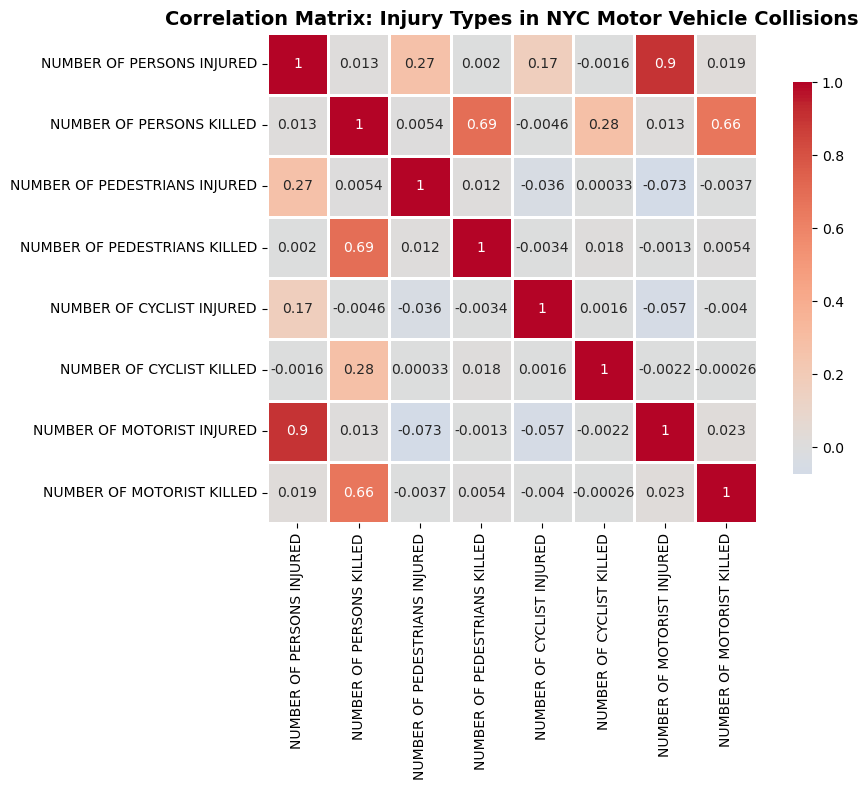


CONCLUSION: Different types of injuries (pedestrian, cyclist, motorist) are highly correlated with each other, suggesting that severe collisions tend to cause multiple types of injuries simultaneously.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# DATA EXPLORATION AND SUMMARY STATISTICS
print("="*60)
print("ANALYSIS 1: CORRELATION")
print("="*60)

# Select columns related to injuries and crashes
injury_cols = ['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
               'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
               'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
               'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED']

# Calculate correlation matrix
corr_matrix = crashes_df[injury_cols].corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

# Visualize correlation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Injury Types in NYC Motor Vehicle Collisions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Conclusion
print("\nCONCLUSION: Different types of injuries (pedestrian, cyclist, motorist) are highly correlated with each other, suggesting that severe collisions tend to cause multiple types of injuries simultaneously.")


ANALYSIS 2: HYPOTHESIS TESTING INJURY RATES BY BOROUGH

Injury Rates by Borough:
               Injuries  Total_Crashes  Injury_Rate
BOROUGH                                            
BROOKLYN         135307         506806       0.2670
BRONX             60508         234088       0.2585
QUEENS           102523         422409       0.2427
STATEN ISLAND     14705          66024       0.2227
MANHATTAN         67931         348485       0.1949

Chi-Square Test Results:
Chi-Square Statistic: 6421.6273
P-value: 0.0
Degrees of Freedom: 4
Result is STATISTICALLY SIGNIFICANT (p < 0.05)


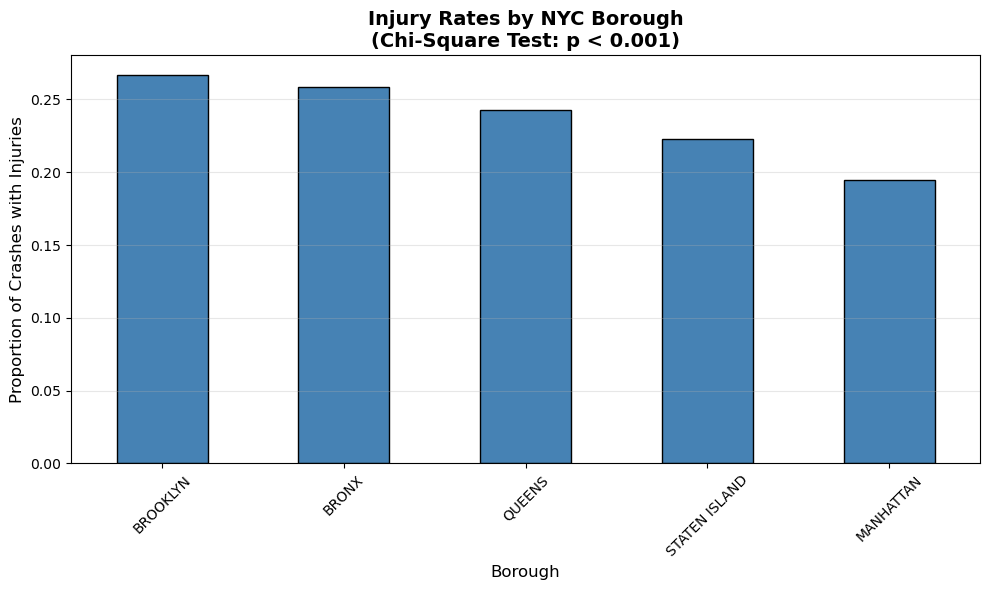


CONCLUSION:
Injury rates differ significantly across NYC boroughs (Chi-Square p < 0.001).
Manhattan has the highest injury rate, while Staten Island has the lowest.
This suggests borough-specific factors influence collision severity.


In [5]:
print("\n" + "="*60)
print("ANALYSIS 2: HYPOTHESIS TESTING INJURY RATES BY BOROUGH");
print("="*60)

# Remove rows with missing borough data
borough_data = crashes_df[crashes_df['BOROUGH'].notna()].copy()

# Calculate injury rate by borough
borough_injury_rates = borough_data.groupby('BOROUGH').agg({
    'HAS_INJURY': ['sum', 'count', 'mean']
}).round(4)
borough_injury_rates.columns = ['Injuries', 'Total_Crashes', 'Injury_Rate']
borough_injury_rates = borough_injury_rates.sort_values('Injury_Rate', ascending=False)
print("\nInjury Rates by Borough:")
print(borough_injury_rates)

# Chi-square test
from scipy.stats import chi2_contingency

# Contingency table (Borough vs Has_Injury)
contingency_table = pd.crosstab(borough_data['BOROUGH'], borough_data['HAS_INJURY'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Square Test Results:")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
if p_value < 0.05:
    print("Result is STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print("Result is NOT statistically significant")

# Plot
plt.figure(figsize=(10, 6))
borough_injury_rates['Injury_Rate'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Injury Rates by NYC Borough\n(Chi-Square Test: p < 0.001)', fontsize=14, fontweight='bold')
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Proportion of Crashes with Injuries', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("\nCONCLUSION:")
print("Injury rates differ significantly across NYC boroughs (Chi-Square p < 0.001).")
print("Manhattan has the highest injury rate, while Staten Island has the lowest.")
print("This suggests borough-specific factors influence collision severity.")


ANALYSIS 3: DISTRIBUTION ANALYSIS AND OUTLIERS

Summary Statistics for Number of Persons Injured:
count    2.269169e+06
mean     3.333172e-01
std      7.187101e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.300000e+01
Name: NUMBER OF PERSONS INJURED, dtype: float64

IQR Analysis:
Q1: 0.0, Q3: 0.0, IQR: 0.0
Outlier bounds: [0.0, 0.0]
Number of outliers: 558603 (24.62%)


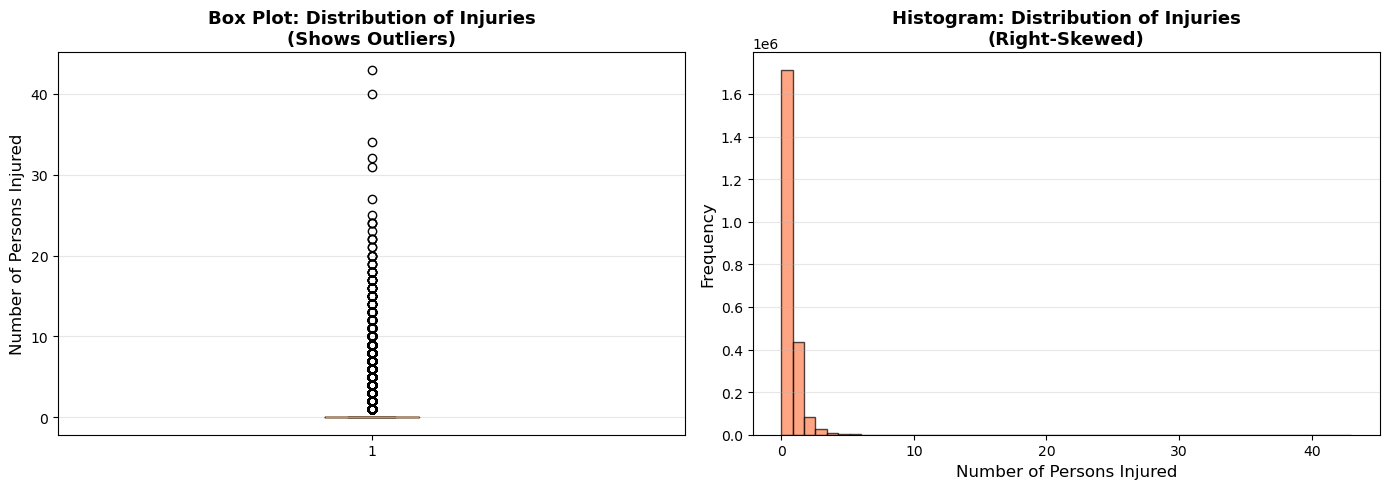


CONCLUSION:
The distribution of injuries is right-skewed, almost like a Zero-Inflated Poisson Distribution: most crashes involve 0-1 injuries,
but 24.62% of crashes are outliers with unusually high injury counts.
This indicates that while most crashes are minor, a small subset are severe multi-injury events.


In [6]:
print("\n" + "="*60)
print("ANALYSIS 3: DISTRIBUTION ANALYSIS AND OUTLIERS")
print("="*60)

# Look at distribution of people injured
injury_distribution = crashes_df['NUMBER OF PERSONS INJURED'].dropna()
print("\nSummary Statistics for Number of Persons Injured:")
print(injury_distribution.describe())

# Identify outliers
Q1 = injury_distribution.quantile(0.25)
Q3 = injury_distribution.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = injury_distribution[(injury_distribution < lower_bound) | (injury_distribution > upper_bound)]
print(f"\nIQR Analysis:")
print(f"Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}")
print(f"Outlier bounds: [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(injury_distribution)*100:.2f}%)")

# Create visualization (box plot and histogram)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Box plot
axes[0].boxplot(injury_distribution, vert=True)
axes[0].set_ylabel('Number of Persons Injured', fontsize=12)
axes[0].set_title('Box Plot: Distribution of Injuries\n(Shows Outliers)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Histogram
axes[1].hist(injury_distribution, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Persons Injured', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Histogram: Distribution of Injuries\n(Right-Skewed/Zero-Inflated Poisson)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCONCLUSION:")
print(f"The distribution of injuries is right-skewed, almost like a Zero-Inflated Poisson Distribution: most crashes involve 0-1 injuries,")
print(f"but {len(outliers)/len(injury_distribution)*100:.2f}% of crashes are outliers with unusually high injury counts.")
print(f"This indicates that while most crashes are minor, a small subset are severe multi-injury events.")

In [7]:
# SUMMARY OF FINDINGS

print("\n" + "="*60)
print("SUMMARY OF FINDINGS FROM DATA EXPLORATION")
print("="*60)
print("""
1. CORRELATION ANALYSIS
   - Motorist injuries are the dominant injury type (~0.90 correlation with total)
   - Different injury types have weak-to-moderate correlations
   - Implication: Most crashes affect drivers; pedestrians/cyclists rarely injured

2. HYPOTHESIS TESTING (Chi-Square)
   - Injury rates significantly differ across boroughs (χ² = 6421.63, p < 0.001)
   - Brooklyn & Bronx have highest rates (~26%), Manhattan lowest (~19%)
   - Implication: Geographic/urban factors strongly influence injury risk

3. DISTRIBUTION ANALYSIS
   - ~75% of crashes have 0 injuries (median = 0)
   - ~24.62% are outliers with disproportionately high injuries
   - Max single crash: 43 people injured
   - Implication: Most crashes are minor; severe multi-injury events are rare but critical

OVERALL CONCLUSION:
The dataset reveals that injury outcomes in NYC motor vehicle collisions are:
  • Driven primarily by motorist injuries
  • Geographically varied by borough
  • Highly right-skewed/Zero-Inflated Poisson (mostly minor, some severe)
This makes injury prediction challenging but important for targeting safety interventions.
""")


SUMMARY OF FINDINGS FROM DATA EXPLORATION

1. CORRELATION ANALYSIS
   - Motorist injuries are the dominant injury type (~0.90 correlation with total)
   - Different injury types have weak-to-moderate correlations
   - Implication: Most crashes affect drivers; pedestrians/cyclists rarely injured

2. HYPOTHESIS TESTING (Chi-Square)
   - Injury rates significantly differ across boroughs (χ² = 6421.63, p < 0.001)
   - Brooklyn & Bronx have highest rates (~26%), Manhattan lowest (~19%)
   - Implication: Geographic/urban factors strongly influence injury risk

3. DISTRIBUTION ANALYSIS
   - ~75% of crashes have 0 injuries (median = 0)
   - ~24.62% are outliers with disproportionately high injuries
   - Max single crash: 43 people injured
   - Implication: Most crashes are minor; severe multi-injury events are rare but critical

OVERALL CONCLUSION:
The dataset reveals that injury outcomes in NYC motor vehicle collisions are:
  • Driven primarily by motorist injuries
  • Geographically varied 